In [3]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [4]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Netflix theme
plt.style.use("dark_background")
sns.set_palette("Reds")

# Load dataset
df = pd.read_csv("netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [6]:
# Convert date
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Fill missing values
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')

# Drop duplicates
df.drop_duplicates(inplace=True)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   str           
 1   type          8807 non-null   str           
 2   title         8807 non-null   str           
 3   director      6173 non-null   str           
 4   cast          7982 non-null   str           
 5   country       8807 non-null   str           
 6   date_added    8709 non-null   datetime64[us]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   str           
 9   duration      8804 non-null   str           
 10  listed_in     8807 non-null   str           
 11  description   8807 non-null   str           
dtypes: datetime64[us](1), int64(1), str(10)
memory usage: 3.7 MB


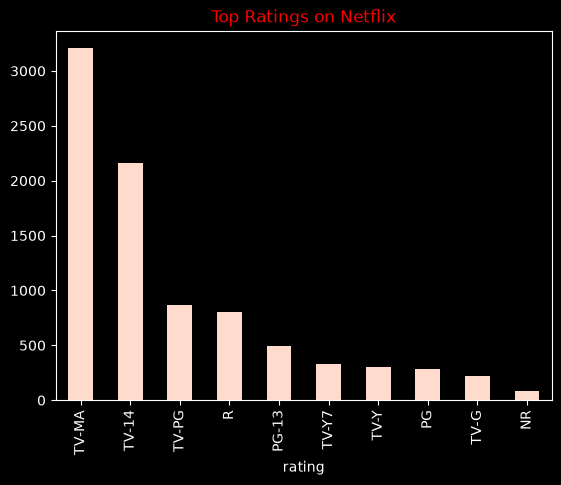

In [8]:
df['rating'].value_counts().head(10).plot(kind='bar')
plt.title("Top Ratings on Netflix", color='red')
plt.show()

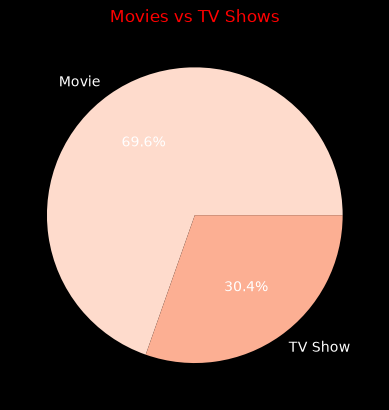

In [9]:
df['type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Movies vs TV Shows", color='red')
plt.ylabel("")
plt.show()

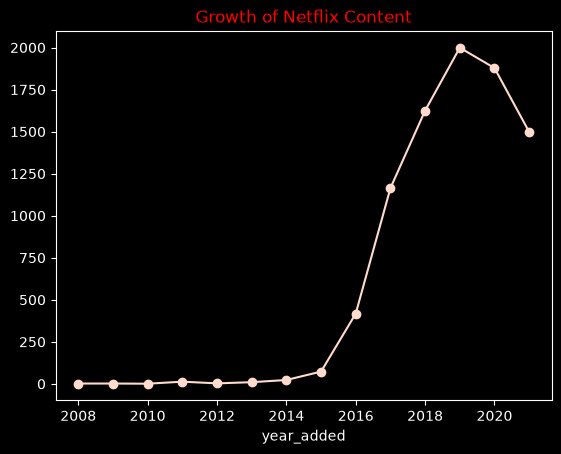

In [10]:
df['year_added'] = df['date_added'].dt.year
df['year_added'].value_counts().sort_index().plot(kind='line', marker='o')

plt.title("Growth of Netflix Content", color='red')
plt.show()

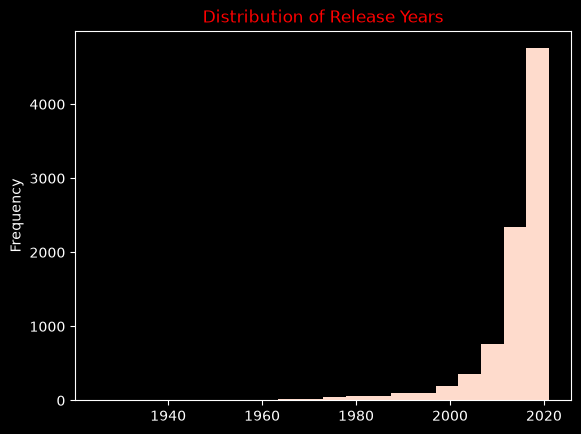

In [11]:
df['release_year'].plot(kind='hist', bins=20)
plt.title("Distribution of Release Years", color='red')
plt.show()

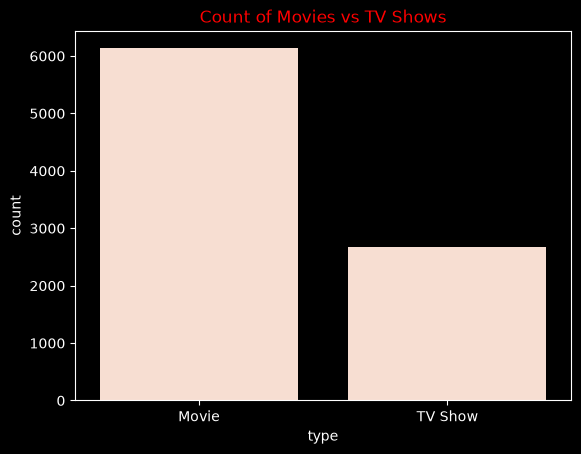

In [12]:
sns.countplot(x='type', data=df)
plt.title("Count of Movies vs TV Shows", color='red')
plt.show()

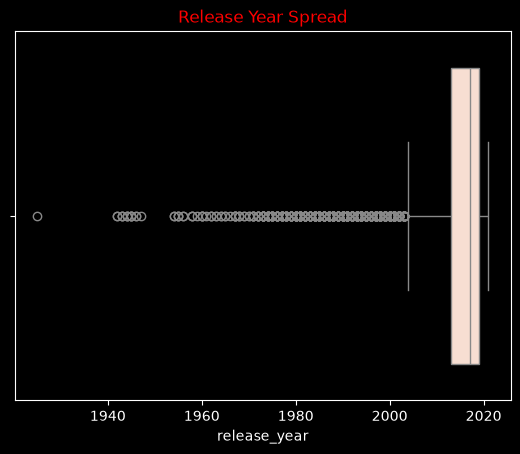

In [13]:
sns.boxplot(x=df['release_year'])
plt.title("Release Year Spread", color='red')
plt.show()

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
C:\Users\satya\AppData\Local\Temp\ipykernel_17128\131067948.py:4: SyntaxWarning: invalid escape sequence '\d'
  df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)


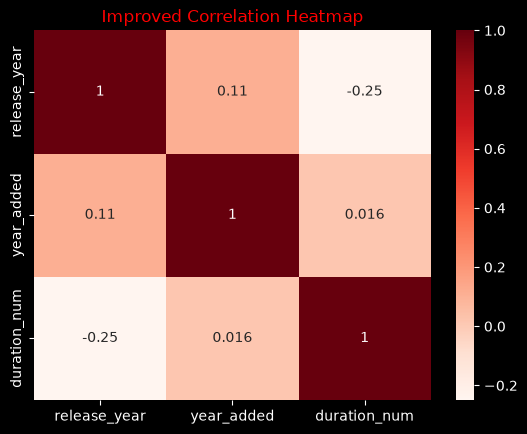

In [16]:
df['year_added'] = df['date_added'].dt.year

# Create duration in numbers (important!)
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)

numeric_df = df[['release_year', 'year_added', 'duration_num']]

sns.heatmap(numeric_df.corr(), annot=True, cmap="Reds")
plt.title("Improved Correlation Heatmap", color='red')
plt.show()

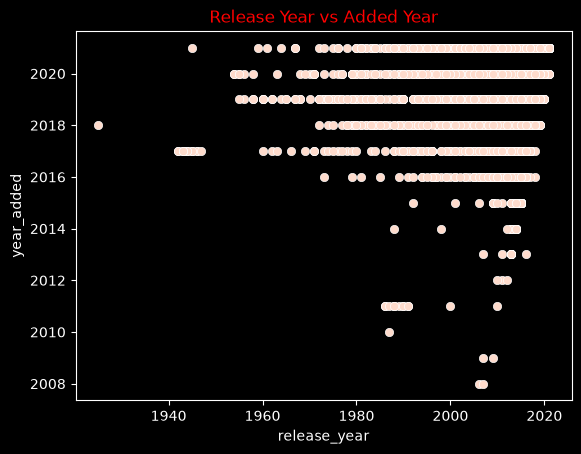

In [15]:
sns.scatterplot(x='release_year', y='year_added', data=df)
plt.title("Release Year vs Added Year", color='red')
plt.show()